# Diffusion-Based Counterfactual Explanations for Medical Image Classification

# 1. Dataset

I use the **Computed Tomography Images for Intracranial Hemorrhage Detection and Segmentation** dataset introduced by Hssayeni et al. [1].

The dataset contains head CT scans from **82 patients**, including patients with and without intracranial hemorrhage (ICH). Each scan consists of approximately 30 axial slices and provides both brain- and bone-window images. Hemorrhage regions were annotated by radiologists [1].

For this project, I use the **brain-window CT images** and formulate the task as a binary classification problem:

- **ICH**: intracranial hemorrhage is present.
- **Non-ICH**: no intracranial hemorrhage is present.

The dataset is organized by patient, which is important for avoiding data leakage. I therefore preserve the patient-level organization throughout the project and perform all train/validation/test splits at the patient level rather than at the individual slice level.

The dataset also provides slice-level annotations for five hemorrhage types: intraventricular, intraparenchymal, subarachnoid, epidural, and subdural hemorrhage. These annotations will be retained for later analysis.

### Reference

[1] Hssayeni, M. (2019). *Computed Tomography Images for Intracranial Hemorrhage Detection and Segmentation*. PhysioNet. doi:10.13026/w8q8-ky94


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from src.data_loading import (
    load_diagnosis,
    load_demographics,
    load_ct_image,
)

DATA_DIR = Path("data")

diagnosis_df = load_diagnosis(DATA_DIR)
demographics_df = load_demographics(DATA_DIR)

print(f"Patients: {len(demographics_df):,}")
print(f"Slice-level records: {len(diagnosis_df):,}")

Patients: 82
Slice-level records: 2,501


# 2. Data Exploration

Before preparing the data for model training, we examine its structure, label distribution, and image characteristics.

The exploration focuses on four questions:

1. How is the dataset organized at the patient and slice levels?
2. How are hemorrhage and non-hemorrhage cases distributed?
3. What hemorrhage types are represented?
4. What do representative CT slices look like?

This step is intended to identify relevant properties of the dataset and potential issues that may affect the subsequent modeling experiments.

## 2.1 Dataset Structure

The CT images are organized by patient, with separate directories for brain- and bone-window images.

We first verify the number of patients and inspect the structure of a representative patient directory.

In [2]:
patients_dir = DATA_DIR / "Patients_CT"

patient_dirs = sorted(path for path in patients_dir.iterdir() if path.is_dir())

print(f"Number of patient directories: {len(patient_dirs)}")

example_patient = patient_dirs[0]

print(f"\nExample patient: {example_patient.name}")
print("Available windows:", [path.name for path in example_patient.iterdir()])

brain_slices = list((example_patient / "brain").glob("*.jpg"))
bone_slices = list((example_patient / "bone").glob("*.jpg"))

print(f"Brain-window slices: {len(brain_slices)}")
print(f"Bone-window slices: {len(bone_slices)}")

Number of patient directories: 82

Example patient: 049
Available windows: ['brain', 'bone']
Brain-window slices: 42
Bone-window slices: 33


## 2.2 Patient and Slice Statistics

Although the diagnosis annotations are provided at the slice level, the patient remains the fundamental unit for data partitioning.

We therefore examine the number of available brain-window slices per patient and check whether the number of slices varies substantially across scans.

In [3]:
slice_counts = []

for patient_dir in patient_dirs:
    num_slices = len(list((patient_dir / "brain").glob("*.jpg")))

    slice_counts.append(
        {
            "PatientNumber": int(patient_dir.name),
            "NumSlices": num_slices,
        }
    )

slice_counts_df = pd.DataFrame(slice_counts)

print(slice_counts_df["NumSlices"].describe())

count    82.000000
mean     34.378049
std       6.548283
min      21.000000
25%      29.250000
50%      32.000000
75%      39.750000
max      51.000000
Name: NumSlices, dtype: float64


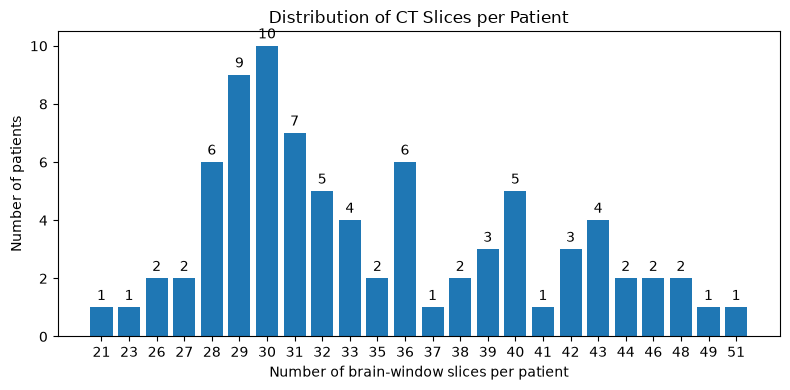

In [4]:
slice_distribution = slice_counts_df["NumSlices"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

bars = plt.bar(
    slice_distribution.index.astype(str),
    slice_distribution.values,
    width=0.8,
)

plt.xlabel("Number of brain-window slices per patient")
plt.ylabel("Number of patients")
plt.title("Distribution of CT Slices per Patient")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

*Comment* : The number of brain-window slices varies across patients. This variation reflects differences in the number of axial slices available for each CT scan.\


## 2.3 Hemorrhage Distribution

The primary classification target is whether intracranial hemorrhage is present on a given slice.

The original metadata uses `No_Hemorrhage` as the negative indicator. I derive the binary `ICH` label from this field while retaining the original hemorrhage-type annotations for subsequent analysis.

I first examine the balance between ICH and non-ICH slices, followed by the distribution of individual hemorrhage types.

In [5]:
diagnosis_df["ICH"] = 1 - diagnosis_df["No_Hemorrhage"]

label_counts = diagnosis_df["ICH"].value_counts().rename(index={0: "Non-ICH", 1: "ICH"})

label_percentages = (
    diagnosis_df["ICH"]
    .value_counts(normalize=True)
    .rename(index={0: "Non-ICH", 1: "ICH"})
    * 100
)

distribution_df = pd.DataFrame(
    {
        "Count": label_counts,
        "Percentage": label_percentages.round(2),
    }
)

distribution_df

,Count,Percentage
ICH,,
Non-ICH,2183,87.29
ICH,318,12.71


In [6]:
hemorrhage_types = [
    "Intraventricular",
    "Intraparenchymal",
    "Subarachnoid",
    "Epidural",
    "Subdural",
]

hemorrhage_type_counts = (
    diagnosis_df[hemorrhage_types].sum().sort_values(ascending=False).rename("Count")
)

hemorrhage_type_counts

Epidural            173
Intraparenchymal     73
Subdural             56
Intraventricular     24
Subarachnoid         18
Name: Count, dtype: int64

## 2.4 Image Inspection

We next inspect representative brain-window CT slices to understand the visual characteristics of the data and verify the correspondence between the images and their metadata labels.

The image loader retrieves individual slices on demand rather than loading the complete dataset into memory. This is sufficient for exploration, while the later training pipeline will use a PyTorch `Dataset` and `DataLoader` to access the complete dataset in batches.

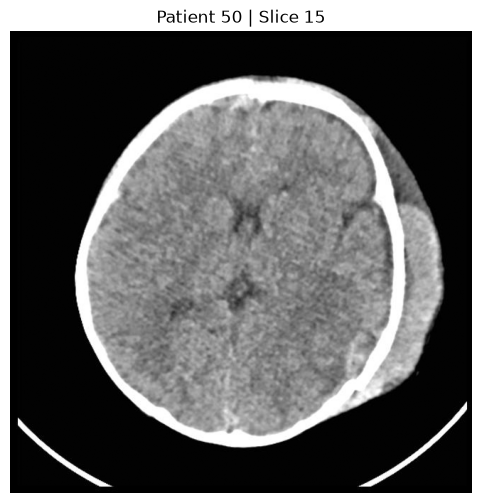

Slice metadata:


PatientNumber       50
SliceNumber         15
Intraventricular     0
Intraparenchymal     1
Subarachnoid         0
Epidural             0
Subdural             0
No_Hemorrhage        0
Fracture_Yes_No      1
ICH                  1
Name: 47, dtype: int64

In [7]:
from src.exploration import (
    get_slice_metadata,
)

patient_id = 50
slice_number = 15

image = load_ct_image(
    DATA_DIR,
    patient_id=patient_id,
    slice_number=slice_number,
    window="brain",
)

slice_info = get_slice_metadata(
    diagnosis_df,
    patient_id=patient_id,
    slice_number=slice_number,
)

plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(f"Patient {patient_id} | Slice {slice_number}")

plt.show()

print("Slice metadata:")
display(slice_info)

## 2.5 Representative ICH and Non-ICH Slices

To obtain an initial view of the classification task, I compare representative slices from the two target classes.

The examples are selected from the slice-level annotations and displayed together with their corresponding labels. This provides a qualitative check of the visual differences and variability that the classifier will need to handle.

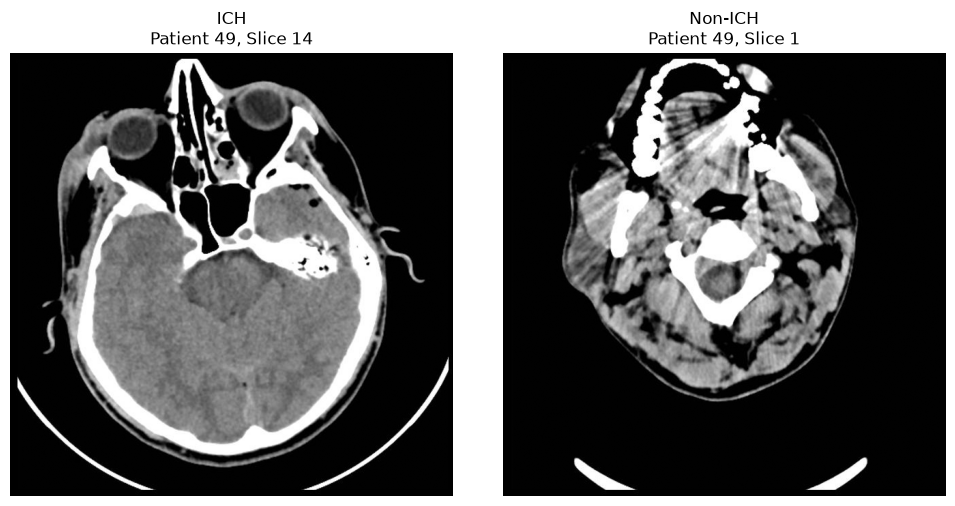

In [8]:
from src.exploration import get_example_slices

examples = get_example_slices(diagnosis_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (label, metadata) in zip(axes, examples.items()):
    image = load_ct_image(
        DATA_DIR,
        patient_id=int(metadata["PatientNumber"]),
        slice_number=int(metadata["SliceNumber"]),
        window="brain",
    )

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"{label}\n"
        f"Patient {int(metadata['PatientNumber'])}, "
        f"Slice {int(metadata['SliceNumber'])}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# 3. Baseline Classifier

## 3.1 Architecture
I use an **ImageNet-pretrained ResNet-18** as the baseline classifier for binary **ICH vs. Non-ICH** classification.

**Why ResNet-18?**

My choice is based on three considerations:

* **Limited data:** The dataset contains only **82 patients**, so training a deep network from scratch is likely to be ineffective. I therefore use **transfer learning** from ImageNet.
* **Model complexity:** ResNet-18 is a relatively compact and well-established architecture. It provides sufficient capacity for the binary classification task while keeping training and experimentation computationally manageable.
* **Project focus:** The classifier is primarily used as the prediction model for the subsequent **diffusion-based counterfactual explanation** experiments. I therefore do not aim to benchmark multiple classification architectures.

**Why not a larger model?**

Larger architectures such as **Wide ResNet-50-2** provide substantially greater capacity and computational cost. Given the small number of independent patients, this additional capacity may increase the risk of overfitting without providing a clear benefit for my objective.

Therefore, I prioritize a **stable, reproducible, and computationally manageable baseline** over a more complex classifier.

## 3.2 Transfer-Learning Strategy

I use **full fine-tuning** of the ImageNet-pretrained ResNet-18 in a single training stage. This allows the pretrained representation to adapt to brain CT images while avoiding the additional complexity of a two-stage freeze-then-unfreeze strategy.

## 3.3 Loss Function

I use **standard cross-entropy loss** with two output classes. The class imbalance is moderate (36 ICH vs. 46 Non-ICH patients), so I use an unweighted loss as the initial baseline and assess its effect through class-specific evaluation metrics.

If imbalance appears to affect performance, **weighted cross-entropy** can be evaluated as a follow-up.


# 4. Data Preparation

The data is prepared for the ResNet-18 classifier using a patient-level split and a common preprocessing pipeline.

## 4.1 Patient-Level Split

Since multiple CT slices belong to the same patient, I use the **patient** as the unit of data splitting.

I first derive one binary ICH label per patient. A patient is considered **ICH** if at least one of their slices is labeled as ICH. Otherwise, the patient is considered **Non-ICH**.

I reserve **17 patients as a held-out test set** and use the remaining **65 patients for model development**. The split is stratified to maintain a similar ICH/Non-ICH distribution in both subsets.

## 4.2 Three-Fold Cross-Validation

I use **3-fold stratified cross-validation** on the 65 development patients to obtain a more reliable estimate of model performance than a single train/validation split.

In each fold, approximately two-thirds of the patients are used for training and one-third for validation, while the 17 test patients remain untouched.

I use **3 folds** to balance multiple validation estimates with the limited number of patients available for each validation set.

## 4.3 Image Preprocessing

I preprocess the brain-window CT images before training the classifier.

- **Resize:** Images are resized to **224 × 224** to match the standard input size of ResNet-18 while keeping computation manageable.
- **Channels:** Grayscale images are replicated across three channels so that the **ImageNet-pretrained weights** can be used without modifying the model's input layer.
- **Normalization:** Images are normalized using the **ImageNet mean and standard deviation**, consistent with the pretrained weights.

Data augmentation is applied separately to the training images only.

## 4.4 Data Augmentation

I apply mild augmentation to the training images to improve robustness to small variations in image orientation and positioning.

I use **horizontal flipping**, **small rotations**, and **small translations**. I avoid vertical flipping, large rotations, and intensity-based transformations because they may produce anatomically unrealistic or clinically misleading images.

Augmentation is applied **only to the training data**. Validation and test images are kept unchanged apart from the required resizing and normalization.

## 4.5 PyTorch Dataset

A custom PyTorch `Dataset` loads each CT slice and its label on demand and applies the corresponding preprocessing transforms.

A `DataLoader` then groups these samples into batches for training and evaluation.

# 5. Training

## 5.1 Optimizer

I use **AdamW** as the optimizer for fine-tuning the pretrained ResNet-18. It provides adaptive learning rates and decoupled weight decay, making it a practical choice for stable fine-tuning on the small dataset.

## 5.2 Learning Rate

I use an initial learning rate of **\(1\times10^{-4}\)**. This relatively small learning rate allows the pretrained ResNet-18 weights to adapt to CT images without making large updates that could quickly disrupt the pretrained representation.

## 5.3 Weight Decay

I use a **weight decay of \(1\times10^{-4}\)** with AdamW as a form of regularization. Since the dataset contains only 82 patients, regularization can help reduce model variance and improve generalization to unseen patients.

## 5.4 Learning-Rate Scheduler

I use **ReduceLROnPlateau** to reduce the learning rate when validation performance stops improving. This allows the model to make smaller updates once training reaches a plateau.

## 5.5 Early Stopping

I use **early stopping based on validation loss** to limit unnecessary training and reduce the risk of overfitting. Training stops when the validation loss does not improve for a predefined number of epochs.

## 5.6 Early-Stopping Patience

I set the **early-stopping patience to 5 epochs**. This allows some fluctuation in validation performance while limiting unnecessary training once the validation loss stops improving.

## 5.7 Maximum Number of Epochs

I set the maximum number of training epochs to **30**. This provides sufficient opportunity for the pretrained model to adapt while allowing early stopping to terminate training when validation performance stops improving.

## 5.8 Metric selection

The evaluation metrics were selected based on preliminary experiments and the characteristics of the dataset. **F1-score** is used as the main metric because of the class imbalance, while **AUROC** provides a threshold-independent measure of the model's discriminative ability. **Sensitivity** is also reported because detecting hemorrhage cases is particularly important in this medical classification task. **Validation loss** is retained for monitoring training dynamics and overfitting.


## 5.9 Training Pipeline Sanity Check

Before running the full training procedure, I perform a **one-epoch sanity check** on the first cross-validation fold.

The goal is to verify that the data pipeline, model, loss, optimizer, and training loop work correctly before starting the full experiment.

In [9]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from src.dataset import CTICHImageDataset
from src.models import create_resnet18
from src.preprocessing import (
    create_patient_labels,
    create_stratified_folds,
    get_eval_transforms,
    get_train_transforms,
    compute_class_weights,
)
from src.training import train_model

patient_labels = create_patient_labels(diagnosis_df)

# Keep the held-out test patients completely separate from cross-validation.
development_patients, test_patients = train_test_split(
    patient_labels,
    test_size=17,
    stratify=patient_labels["ICH"],
    random_state=42,
)

cv_folds = create_stratified_folds(development_patients)

device = torch.device("cpu")

for fold in cv_folds:
    print(f"\n{'=' * 20} Fold {fold['fold']} {'=' * 20}")

    train_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=fold["train"]["PatientNumber"].tolist(),
        transform=get_train_transforms(),
    )

    validation_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=fold["validation"]["PatientNumber"].tolist(),
        transform=get_eval_transforms(),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=32,
        shuffle=False,
    )

    model = create_resnet18(num_classes=2).to(device)

    train_labels = diagnosis_df.loc[
        diagnosis_df["PatientNumber"].isin(fold["train"]["PatientNumber"]), "ICH"
    ].values
    class_weights = compute_class_weights(train_labels).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4,
        weight_decay=1e-4,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    model, history, best_validation_predictions, epoch_states, best_epoch = train_model(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=1,
        patience=5,
    )

print("\nSanity check completed successfully for all 3 folds.")


==================== Fold 1 ====================
Epoch 01/1 | Train Loss: 0.4892 | Train F1: 0.4488 | Val Loss: 0.5828 | Val F1: 0.4509 | Val Sensitivity: 0.4483 | Val Specificity: 0.9188 | Val AUROC: 0.7764 | LR: 1.00e-04

==================== Fold 2 ====================
Epoch 01/1 | Train Loss: 0.4659 | Train F1: 0.4655 | Val Loss: 0.5368 | Val F1: 0.3577 | Val Sensitivity: 0.2558 | Val Specificity: 0.9753 | Val AUROC: 0.8267 | LR: 1.00e-04

==================== Fold 3 ====================
Epoch 01/1 | Train Loss: 0.4796 | Train F1: 0.4595 | Val Loss: 0.4547 | Val F1: 0.4431 | Val Sensitivity: 0.4066 | Val Specificity: 0.9283 | Val AUROC: 0.8554 | LR: 1.00e-04

Sanity check completed successfully for all 3 folds.


## 5.9 Full Cross-Validation Training

I now train the ResNet-18 classifier using the three patient-level cross-validation folds defined earlier.

For each fold, I create separate training and validation datasets, initialize a new pretrained ResNet-18, and train it using the selected optimization and early-stopping settings.

The held-out test patients remain completely untouched during this stage and will only be used for the final evaluation.


In [10]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from src.dataset import CTICHImageDataset
from src.models import create_resnet18
from src.preprocessing import (
    get_eval_transforms,
    get_train_transforms,
)
from src.training import train_model

batch_size = 32
num_epochs = 30
early_stopping_patience = 5

learning_rate = 1e-4
weight_decay = 1e-4

scheduler_factor = 0.5
scheduler_patience = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

num_workers = 4
pin_memory = device.type == "cuda"

fold_results = {}

for fold in cv_folds:
    fold_number = fold["fold"]

    print(f"\n{'=' * 20} Fold {fold_number} {'=' * 20}")

    train_patient_ids = fold["train"]["PatientNumber"].tolist()
    validation_patient_ids = fold["validation"]["PatientNumber"].tolist()

    train_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=train_patient_ids,
        transform=get_train_transforms(),
    )

    validation_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=validation_patient_ids,
        transform=get_eval_transforms(),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    model = create_resnet18(num_classes=2).to(device)

    train_labels = diagnosis_df.loc[
        diagnosis_df["PatientNumber"].isin(train_patient_ids),
        "ICH",
    ].values

    class_weights = compute_class_weights(train_labels).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=scheduler_factor,
        patience=scheduler_patience,
    )

    (
        model,
        history,
        best_validation_predictions,
        epoch_states,
        best_epoch,
    ) = train_model(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=num_epochs,
        patience=early_stopping_patience,
        checkpoint_metric="f1",
    )

    fold_results[fold_number] = {
        "model": model,
        "history": history,
        "best_validation_predictions": best_validation_predictions,
        "epoch_states": epoch_states,
        "best_epoch": best_epoch,
        "train_patient_ids": train_patient_ids,
        "validation_patient_ids": validation_patient_ids,
    }

print("\nFull cross-validation training completed.")

Using device: cpu

==================== Fold 1 ====================
Epoch 01/30 | Train Loss: 0.4924 | Train F1: 0.4523 | Val Loss: 0.4610 | Val F1: 0.4719 | Val Sensitivity: 0.4828 | Val Specificity: 0.9154 | Val AUROC: 0.8379 | LR: 1.00e-04
Epoch 02/30 | Train Loss: 0.3090 | Train F1: 0.6000 | Val Loss: 0.3320 | Val F1: 0.5755 | Val Sensitivity: 0.7011 | Val Specificity: 0.8895 | Val AUROC: 0.9087 | LR: 1.00e-04
Epoch 03/30 | Train Loss: 0.2656 | Train F1: 0.6751 | Val Loss: 0.4447 | Val F1: 0.4743 | Val Sensitivity: 0.6897 | Val Specificity: 0.8169 | Val AUROC: 0.8600 | LR: 1.00e-04
Epoch 04/30 | Train Loss: 0.1938 | Train F1: 0.7494 | Val Loss: 0.4523 | Val F1: 0.4161 | Val Sensitivity: 0.3563 | Val Specificity: 0.9465 | Val AUROC: 0.8779 | LR: 1.00e-04
Epoch 05/30 | Train Loss: 0.1758 | Train F1: 0.7832 | Val Loss: 0.4378 | Val F1: 0.5075 | Val Sensitivity: 0.7816 | Val Specificity: 0.8048 | Val AUROC: 0.8857 | LR: 5.00e-05
Epoch 06/30 | Train Loss: 0.1559 | Train F1: 0.8215 | Val

In [11]:
from src.calibration import compute_brier_score, compute_ece

for fold, results in fold_results.items():
    labels = results["best_validation_predictions"]["labels"]
    probabilities = results["best_validation_predictions"]["probabilities"]

    brier = compute_brier_score(labels, probabilities)
    ece = compute_ece(labels, probabilities)

    print(f"Fold {fold}")
    print(f"  Brier score: {brier:.4f}")
    print(f"  ECE:         {ece:.4f}")

Fold 1
  Brier score: 0.0947
  ECE:         0.0890
Fold 2
  Brier score: 0.0833
  ECE:         0.0471
Fold 3
  Brier score: 0.1027
  ECE:         0.0568


### Calibration

Calibration measures whether the model's predicted probabilities reflect its actual likelihood of being correct.

For example, among samples predicted with approximately 80% probability, a well-calibrated model should be correct roughly 80% of the time.

The reliability diagram compares:

- **Mean predicted probability** — what the model believes
- **Fraction of positives** — what actually happens

A perfectly calibrated model follows the diagonal line.

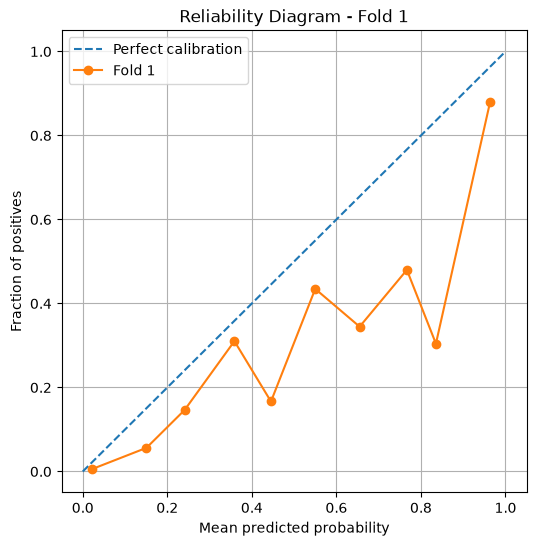

fold 1: fraction of positives : [0.00540541 0.05633803 0.14634146 0.31034483 0.16666667 0.43478261
 0.34482759 0.48       0.30434783 0.88      ] | mean predicted value : [0.02120466 0.15071883 0.2409048  0.35876587 0.44524418 0.55000869
 0.65498316 0.76675062 0.83546313 0.96364824]


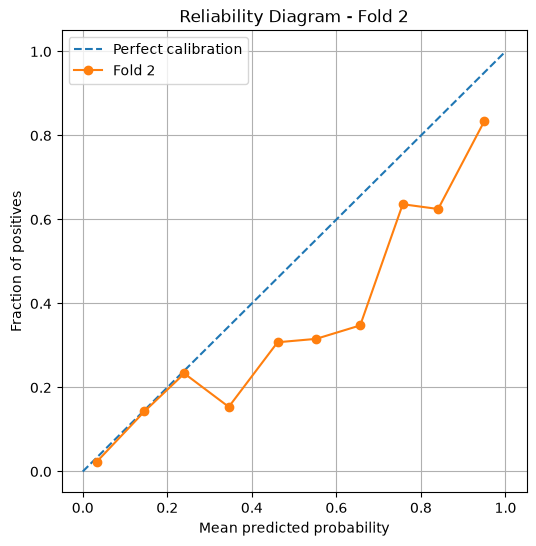

fold 2: fraction of positives : [0.02304147 0.14285714 0.23333333 0.15384615 0.30769231 0.31578947
 0.34782609 0.63636364 0.625      0.83333333] | mean predicted value : [0.03294509 0.14574891 0.24036275 0.34538553 0.46087272 0.55203169
 0.65633626 0.75695814 0.84070012 0.94954659]


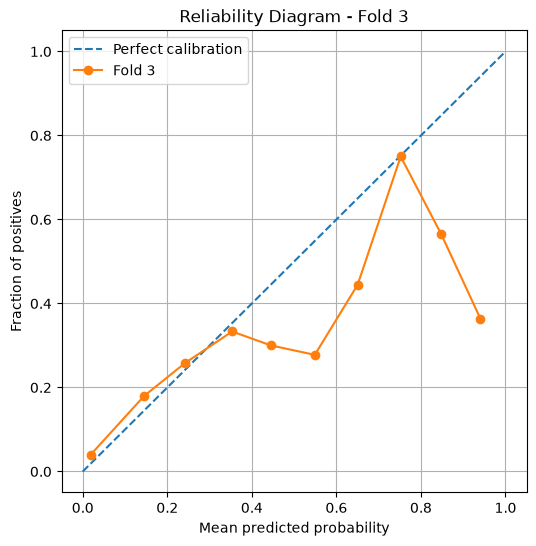

fold 3: fraction of positives : [0.0399061  0.18       0.25806452 0.33333333 0.3        0.27777778
 0.44444444 0.75       0.56521739 0.36363636] | mean predicted value : [0.01865809 0.14536472 0.24177348 0.35340891 0.44558935 0.54892408
 0.65021675 0.7521033  0.8479065  0.94084291]


In [12]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

for fold, results in fold_results.items():
    labels = results["best_validation_predictions"]["labels"]
    probabilities = results["best_validation_predictions"]["probabilities"]

    fraction_of_positives, mean_predicted_value = calibration_curve(
        labels,
        probabilities,
        n_bins=10,
        strategy="uniform",
    )

    plt.figure(figsize=(6, 6))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    plt.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        label=f"Fold {fold}",
    )

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"Reliability Diagram - Fold {fold}")
    plt.legend()
    plt.grid(True)
    plt.show()
    print(
        f"fold {fold}: fraction of positives : {fraction_of_positives} | mean predicted value : {mean_predicted_value}"
    )

### Temperature Scaling

Temperature scaling is a post-hoc calibration method that adjusts the model's confidence without changing its predicted class.

The model's logits are divided by a learned temperature $T$ before applying softmax:

$$
p = \text{softmax}\left(\frac{z}{T}\right)
$$

The temperature is learned on the validation set by minimizing the Negative Log-Likelihood (NLL).

- $T = 1$: no change
- $T > 1$: probabilities become softer and less confident
- $T < 1$: probabilities become sharper and more confident

A lower NLL after scaling indicates improved probability estimates.

In [13]:
from src.calibration import fit_temperature
import torch
import torch.nn.functional as F


def compute_nll(logits, labels):
    logits = torch.tensor(logits, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)

    return F.cross_entropy(logits, labels).item()

for fold, results in fold_results.items():
    logits = results["best_validation_predictions"]["logits"]
    labels = results["best_validation_predictions"]["labels"]

    temperature = fit_temperature(logits, labels)
    nll_before = compute_nll(logits, labels)

    temperature = fit_temperature(logits, labels)

    scaled_logits = torch.tensor(logits, dtype=torch.float32) / temperature
    nll_after = F.cross_entropy(
        scaled_logits,
        torch.tensor(labels, dtype=torch.long),
    ).item()
    print(f"Fold {fold}: ")
    print(f"NLL before: {nll_before:.4f}")
    print(f"NLL after:  {nll_after:.4f}")

    print(f"T = {temperature:.4f}\n=================")

Fold 1: 
NLL before: 0.2856
NLL after:  0.2856
T = 1.0230


/home/afaf/workspace/diffusion-counterfactual-xai/src/calibration.py:38: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  logits = torch.tensor(logits, dtype=torch.float32)


Fold 2: 
NLL before: 0.2733
NLL after:  0.2733
T = 0.9938
Fold 3: 
NLL before: 0.3418
NLL after:  0.3197
T = 1.4855


## Uncertainty Estimation with MC Dropout

MC Dropout estimates predictive uncertainty by performing multiple stochastic forward passes through the model with dropout enabled.

For each image, the model produces several probability estimates.

The mean probability is used as the final prediction, while the standard deviation across predictions represents uncertainty.

- Similar predictions → low uncertainty
- Variable predictions → high uncertainty

This allows us to identify cases where the model is less certain and may benefit from human review.

In [14]:
from src.uncertainty import mc_dropout_predict
from torch.utils.data import DataLoader
import torch


def collect_uncertainty_predictions(
    model,
    data_loader,
    device,
    n_samples=20,
):
    model.eval()

    all_labels = []
    all_probabilities = []
    all_uncertainties = []
    all_predictions = []

    for images, labels in data_loader:
        results = mc_dropout_predict(
            model=model,
            images=images,
            device=device,
            n_samples=n_samples,
        )

        all_labels.extend(labels.numpy())
        all_probabilities.extend(
            results["probabilities"].cpu().numpy()
        )
        all_uncertainties.extend(
            results["uncertainty"].cpu().numpy()
        )
        all_predictions.extend(
            results["predictions"].cpu().numpy()
        )

    return {
        "labels": all_labels,
        "probabilities": all_probabilities,
        "uncertainties": all_uncertainties,
        "predictions": all_predictions,
    }


for fold, results in fold_results.items():

    model = results["model"]

    validation_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=results["validation_patient_ids"],
        transform=get_eval_transforms(),
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    uncertainty_results = collect_uncertainty_predictions(
        model=model,
        data_loader=validation_loader,
        device=device,
        n_samples=20,
    )

    results["uncertainty_predictions"] = uncertainty_results

    print(f"Fold {fold}")
    print(f"Validation patients: {len(results['validation_patient_ids'])}")
    print(f"Validation slices: {len(validation_dataset)}")
    print(
        f"Mean uncertainty: "
        f"{torch.tensor(uncertainty_results['uncertainties']).mean():.4f}"
    )

Fold 1
Validation patients: 22
Validation slices: 666
Mean uncertainty: 0.0581
Fold 2
Validation patients: 22
Validation slices: 694
Mean uncertainty: 0.0573
Fold 3
Validation patients: 21
Validation slices: 635
Mean uncertainty: 0.0389


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for fold, results in fold_results.items():
    uncertainty_results = results["uncertainty_predictions"]

    uncertainties = np.asarray(
        uncertainty_results["uncertainties"]
    )
    labels = np.asarray(
        uncertainty_results["labels"]
    )
    predictions = np.asarray(
        uncertainty_results["predictions"]
    )

    correct = predictions == labels

    correct_uncertainty = uncertainties[correct]
    incorrect_uncertainty = uncertainties[~correct]

    print(f"\n{'=' * 40}")
    print(f"Fold {fold}")
    print(f"{'=' * 40}")

    print(f"Correct predictions:   {correct.sum()}")
    print(f"Incorrect predictions: {(~correct).sum()}")

    print(
        f"Mean uncertainty - correct:   "
        f"{correct_uncertainty.mean():.4f}"
    )
    print(
        f"Mean uncertainty - incorrect: "
        f"{incorrect_uncertainty.mean():.4f}"
    )

    print(
        f"Median uncertainty - correct:   "
        f"{np.median(correct_uncertainty):.4f}"
    )
    print(
        f"Median uncertainty - incorrect: "
        f"{np.median(incorrect_uncertainty):.4f}"
    )

    # Plot
    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [correct_uncertainty, incorrect_uncertainty],
        tick_labels=["Correct", "Incorrect"],
    )

    plt.ylabel("MC Dropout uncertainty")
    plt.title(f"Uncertainty by prediction correctness - Fold {fold}")
    plt.grid(axis="y", alpha=0.3)

    plt.show()


Fold 1
Correct predictions:   572
Incorrect predictions: 94
Mean uncertainty - correct:   0.0481
Mean uncertainty - incorrect: 0.1190
Median uncertainty - correct:   0.0252
Median uncertainty - incorrect: 0.1217


TypeError: boxplot() got an unexpected keyword argument 'labels'

<Figure size 700x500 with 0 Axes>